# Objective

The objective of this experiment is to build and visualize a Decision Tree model using Scikit-learn to classify data and analyze its performance. The model helps in understanding how decisions are made based on different features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [6]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


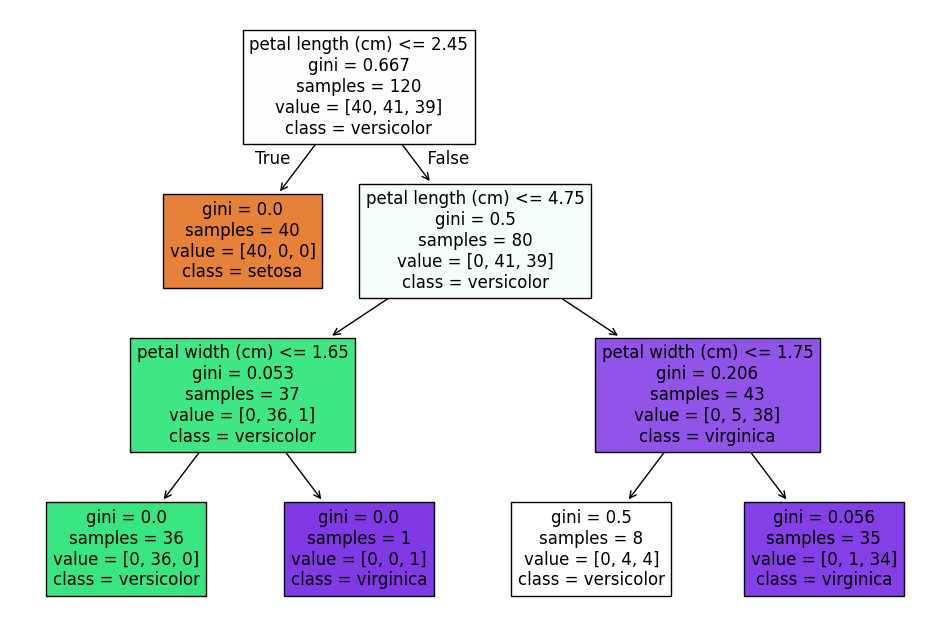

In [7]:
plt.figure(figsize=(12,8))
plot_tree(model, feature_names=feature_names, class_names=class_names, filled=True)
plt.show()

In [8]:
importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
    })

print(importance.sort_values(by='Importance', ascending=False))

             Feature  Importance
2  petal length (cm)    0.934626
3   petal width (cm)    0.065374
1   sepal width (cm)    0.000000
0  sepal length (cm)    0.000000


In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Gini model
gini_model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
gini_model.fit(X_train, y_train)
gini_pred = gini_model.predict(X_test)

# Entropy model
entropy_model = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
entropy_model.fit(X_train, y_train)
entropy_pred = entropy_model.predict(X_test)

# Accuracy comparison
print("Gini Accuracy:", accuracy_score(y_test, gini_pred))
print("Entropy Accuracy:", accuracy_score(y_test, entropy_pred))

Gini Accuracy: 1.0
Entropy Accuracy: 1.0


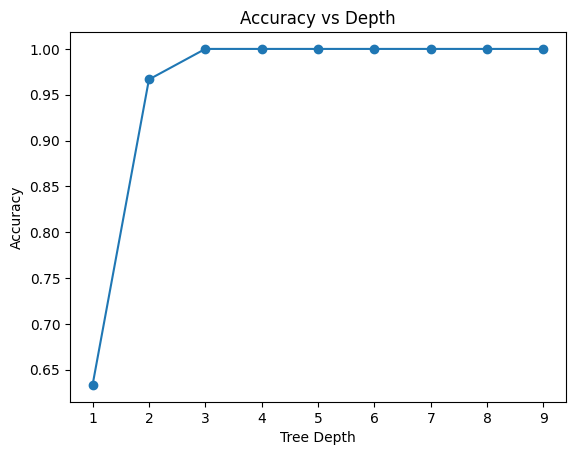

In [10]:
depths = range(1, 10)
accuracies = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot
import matplotlib.pyplot as plt

plt.plot(depths, accuracies, marker='o')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Depth")
plt.show()

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}


In [12]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))

Final Accuracy: 1.0


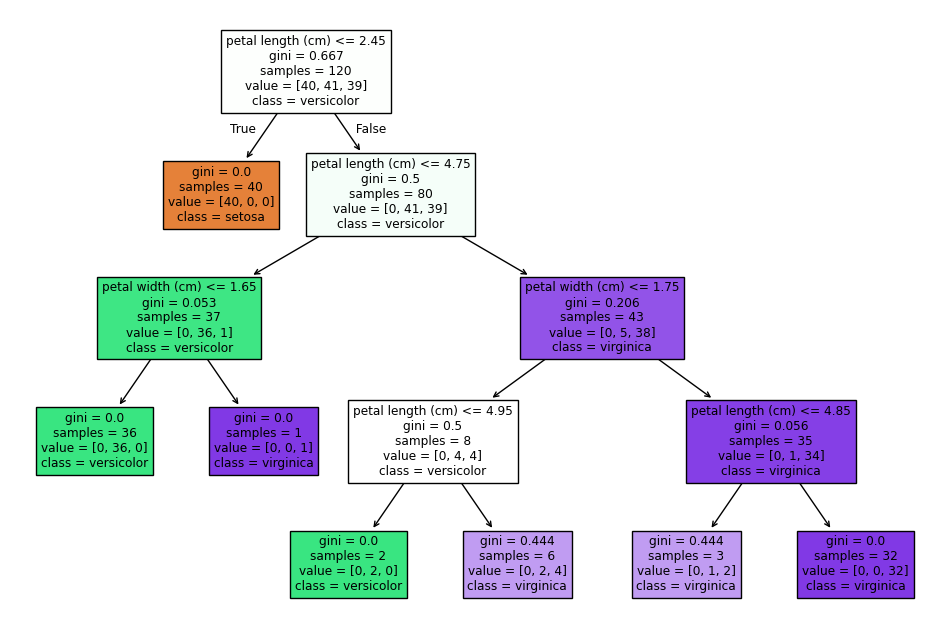

In [13]:
plt.figure(figsize=(12,8))
plot_tree(best_model, feature_names=feature_names, class_names=class_names, filled=True)
plt.show()

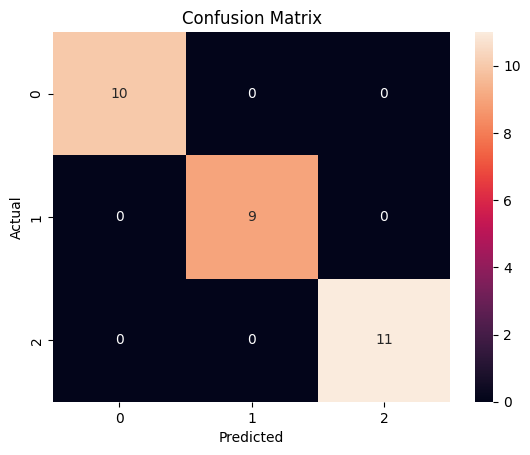

In [14]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()